In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# =========================
# ✅ Mac 한글 폰트 설정
# =========================
plt.rcParams["font.family"] = "AppleGothic"      # 맥 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지


In [4]:
import pandas as pd

# 1) parquet 로드
sha_df = pd.read_parquet("../sha_df.parquet")

# 2) 컬럼명 확인 (혹시 이름 다를 수도 있으니까)
print(sha_df.columns)
sha_df.head(3)


Index(['고객ID', '기준년월', '해지여부', '연령대', '가입기간', '총사용일수', '만료잔여기간', '약정만료일',
       '구형장비여부', '최근1달_셋톱장애경험', '최근1달_민원접수', '최근1달_해지방어', '유튜브_사용여부',
       '넷플릭스_사용여부', '월평균시청시간', '재택비율', '마지막시청_경과일', '키즈시청건수'],
      dtype='object')


,고객ID,기준년월,해지여부,연령대,가입기간,총사용일수,만료잔여기간,약정만료일,구형장비여부,최근1달_셋톱장애경험,최근1달_민원접수,최근1달_해지방어,유튜브_사용여부,넷플릭스_사용여부,월평균시청시간,재택비율,마지막시청_경과일,키즈시청건수
0,6c2fb1fb0b1e316975157671e03d0e2eb3d250a7373321...,202303,유지,50대,6개월미만,45,약정만료전 12개월이상,20260213,N,N,Y,N,N,N,4.46,10.0,일주일내,2.0
1,39b9ff560dbcbe4e138f04fd082d55d921c5528f1cc279...,202303,유지,70대,6개월미만,45,약정만료전 12개월이상,20260213,N,N,Y,N,N,N,4.57,10.0,일주일내,1.0
2,db168b085b5c0cd2d21faab70ceb4ec36c5409aea1f8f4...,202303,유지,70대,6개월미만,44,약정만료전 12개월이상,20260214,N,N,Y,N,N,N,6.32,20.0,일주일내,0.0


In [ ]:
import pandas as pd

# 1) parquet 로드
sha_df = pd.read_parquet("sha_df.parquet")

KEY_COLS = ["고객ID", "기준년월"]
FLAG_COL = "넷플릭스_사용여부"   # 실제 컬럼명으로

# 3) 공백/결측/소문자 섞임 방지: Y/N만 남기기
tmp = sha_df[KEY_COLS + [FLAG_COL]].copy()
tmp[FLAG_COL] = tmp[FLAG_COL].astype(str).str.strip().str.upper()

# 4) (고객, 월) 그룹 안에서 넷플릭스_사용여부의 유니크 개수a 계산
g = (
    tmp.groupby(KEY_COLS)[FLAG_COL]
       .nunique(dropna=False)
       .reset_index(name="n_unique")
)

# 5) 유니크가 2개 이상이면 = 같은 고객/월 안에서 Y와 N이 섞여있다는 뜻
flip_keys = g[g["n_unique"] >= 2]

print("✅ 같은 (고객ID, 기준년월) 내에서 넷플릭스_사용여부가 바뀌는 케이스 수:", len(flip_keys))
display(flip_keys.head(20))

✅ 같은 (고객ID, 기준년월) 내에서 넷플릭스_사용여부가 바뀌는 케이스 수: 0


,고객ID,기준년월,n_unique


In [4]:
import pandas as pd
import numpy as np

ID_COL     = "고객ID"
MT_COL     = "기준년월"
NFLX_COL   = "넷플릭스_사용여부"
CANCEL_COL = "해지여부"

df = sha_df[[ID_COL, MT_COL, NFLX_COL, CANCEL_COL]].copy()

# 정규화
df[NFLX_COL] = df[NFLX_COL].astype(str).str.strip().str.upper()

# Y/N 아닌 값은 결측 처리
df.loc[~df[NFLX_COL].isin(["Y", "N"]), NFLX_COL] = np.nan

# ✅ 넷플릭스 사용여부 결측 제거
df = df.dropna(subset=[NFLX_COL]).reset_index(drop=True)

print("결측 제거 후 행 수:", len(df))
df.head()


결측 제거 후 행 수: 22893471


,고객ID,기준년월,넷플릭스_사용여부,해지여부
0,6c2fb1fb0b1e316975157671e03d0e2eb3d250a7373321...,202303,N,유지
1,39b9ff560dbcbe4e138f04fd082d55d921c5528f1cc279...,202303,N,유지
2,db168b085b5c0cd2d21faab70ceb4ec36c5409aea1f8f4...,202303,N,유지
3,59a02dfe6d4e5e4ffc1b295dc0ebf0fdf7ffc37321f653...,202303,N,유지
4,6f415993f9b6968f3b7bd8b2188f8651dfdc7e50e3022a...,202303,N,유지


In [5]:
df["cancel_bin"] = (df[CANCEL_COL].astype(str).str.strip() == "해지").astype("int8")
df["cancel_bin"].value_counts()


cancel_bin
0    21583829
1     1309642
Name: count, dtype: int64

In [6]:
df["nflx_y_flag"] = (df[NFLX_COL] == "Y").astype("int8")
df["nflx_n_flag"] = (df[NFLX_COL] == "N").astype("int8")

per_month = (
    df.groupby([ID_COL, MT_COL], observed=True, sort=False)
      .agg(
          nflx_y_flag=("nflx_y_flag", "max"),
          nflx_n_flag=("nflx_n_flag", "max"),
          cancel_month=("cancel_bin", "max"),
      )
      .reset_index()
)

print("per_month 행 수:", len(per_month))
per_month.head()


per_month 행 수: 22473534


,고객ID,기준년월,nflx_y_flag,nflx_n_flag,cancel_month
0,6c2fb1fb0b1e316975157671e03d0e2eb3d250a7373321...,202303,0,1,0
1,39b9ff560dbcbe4e138f04fd082d55d921c5528f1cc279...,202303,0,1,0
2,db168b085b5c0cd2d21faab70ceb4ec36c5409aea1f8f4...,202303,0,1,0
3,59a02dfe6d4e5e4ffc1b295dc0ebf0fdf7ffc37321f653...,202303,0,1,0
4,6f415993f9b6968f3b7bd8b2188f8651dfdc7e50e3022a...,202303,0,1,0


In [7]:
cust = (
    per_month.groupby(ID_COL, observed=True, sort=False)
             .agg(
                 total_months=(MT_COL, "nunique"),
                 nflx_y_months=("nflx_y_flag", "sum"),
                 nflx_n_months=("nflx_n_flag", "sum"),
                 cancel_final=("cancel_month", "max"),
             )
             .reset_index()
)

cust["넷플릭스_최종이용여부"] = np.where(
    cust["nflx_y_months"] >= cust["nflx_n_months"], "이용", "미이용"
)

cust.head()


,고객ID,total_months,nflx_y_months,nflx_n_months,cancel_final,넷플릭스_최종이용여부
0,6c2fb1fb0b1e316975157671e03d0e2eb3d250a7373321...,11,1,10,0,미이용
1,39b9ff560dbcbe4e138f04fd082d55d921c5528f1cc279...,11,3,8,0,미이용
2,db168b085b5c0cd2d21faab70ceb4ec36c5409aea1f8f4...,11,2,9,0,미이용
3,59a02dfe6d4e5e4ffc1b295dc0ebf0fdf7ffc37321f653...,11,0,11,0,미이용
4,6f415993f9b6968f3b7bd8b2188f8651dfdc7e50e3022a...,11,1,10,0,미이용


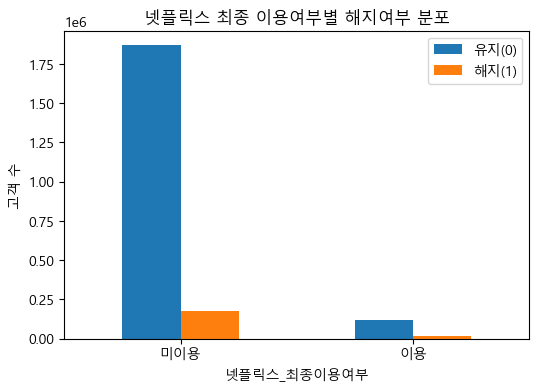

,유지(0),해지(1)
넷플릭스_최종이용여부,,
미이용,1867808,174377
이용,116843,16299


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

ct = pd.crosstab(cust["넷플릭스_최종이용여부"], cust["cancel_final"])
ct.columns = ["유지(0)", "해지(1)"]

ax = ct.plot(kind="bar", figsize=(6,4))
plt.title("넷플릭스 최종 이용여부별 해지여부 분포")
plt.ylabel("고객 수")
plt.xticks(rotation=0)
plt.show()

display(ct)


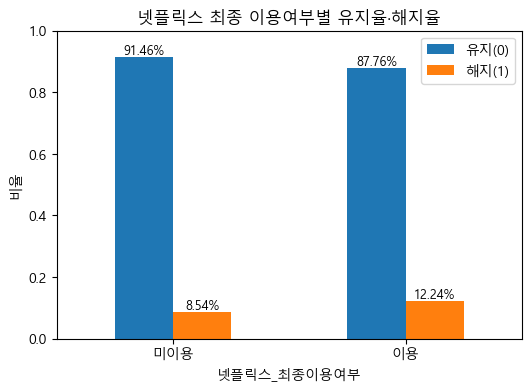

,유지(0),해지(1)
넷플릭스_최종이용여부,,
미이용,0.914613,0.085387
이용,0.877582,0.122418


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 교차표 (건수)
ct = pd.crosstab(cust["넷플릭스_최종이용여부"], cust["cancel_final"])
ct.columns = ["유지(0)", "해지(1)"]

# 2) 행 기준 비율로 변환 (유지율 + 해지율)
ct_rate = ct.div(ct.sum(axis=1), axis=0)

# 3) 비율 기준 막대그래프 (기존 코드와 동일한 형태)
ax = ct_rate.plot(kind="bar", figsize=(6,4))

plt.title("넷플릭스 최종 이용여부별 유지율·해지율")
plt.ylabel("비율")
plt.xticks(rotation=0)
plt.ylim(0, 1)

# 4) 막대 위에 비율 표시
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2%}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

display(ct_rate)


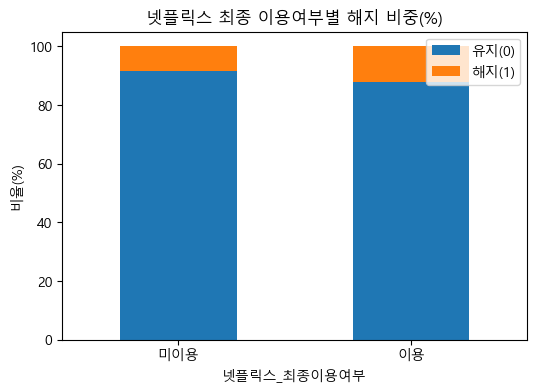

,유지(0),해지(1)
넷플릭스_최종이용여부,,
미이용,91.46,8.54
이용,87.76,12.24


In [9]:
import matplotlib.pyplot as plt

ct_rate = ct.div(ct.sum(axis=1), axis=0) * 100

ax = ct_rate.plot(kind="bar", stacked=True, figsize=(6,4))
plt.title("넷플릭스 최종 이용여부별 해지 비중(%)")
plt.ylabel("비율(%)")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.show()

display(ct_rate.round(2))


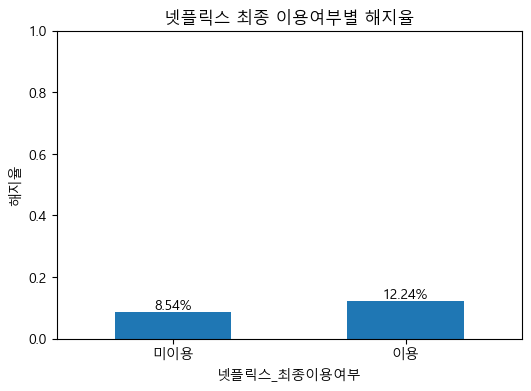

,유지(0),해지(1)
넷플릭스_최종이용여부,,
미이용,0.914613,0.085387
이용,0.877582,0.122418


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 교차표 (건수)
ct = pd.crosstab(cust["넷플릭스_최종이용여부"], cust["cancel_final"])
ct.columns = ["유지(0)", "해지(1)"]

# 2) 행 기준 비율(해지율)로 변환
ct_rate = ct.div(ct.sum(axis=1), axis=0)

# 3) 해지율만 선택
cancel_rate = ct_rate["해지(1)"]

# 4) 그래프
ax = cancel_rate.plot(
    kind="bar",
    figsize=(6, 4),
    ylim=(0, 1)
)

plt.title("넷플릭스 최종 이용여부별 해지율")
plt.ylabel("해지율")
plt.xticks(rotation=0)

# 막대 위에 해지율 표시
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

display(ct_rate)


In [17]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 0) 필수: cancel_final이 0/1 정수인지 보정
cust["cancel_final"] = cust["cancel_final"].round().astype(int)

# 1) 교차표(정수 count) 만들기
ct = pd.crosstab(
    cust["넷플릭스_최종이용여부"],
    cust["cancel_final"]
)

# 열 이름 정리(보기 좋게)
ct = ct.rename(columns={0: "유지(0)", 1: "해지(1)"})

print("=== 교차표(고객 수) ===")
display(ct)

# 2) 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(ct)

print("\n=== Chi-square test 결과 ===")
print(f"χ² (Chi-square statistic) = {chi2:.4f}")
print(f"df (자유도)               = {dof}")
print(f"p-value                   = {p:.6e}")

# 3) 기대빈도표(조건 확인용)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print("\n=== Expected frequencies (기대빈도) ===")
display(expected_df)

# 4) (선택) 검정 조건 체크: 기대빈도 5 미만 존재 여부
low_expected = (expected_df < 5).sum().sum()
print(f"\n기대빈도 5 미만 셀 개수: {low_expected}")


=== 교차표(고객 수) ===


cancel_final,유지(0),해지(1)
넷플릭스_최종이용여부,,
미이용,1867808,174377
이용,116843,16299



=== Chi-square test 결과 ===
χ² (Chi-square statistic) = 2142.8149
df (자유도)               = 1
p-value                   = 0.000000e+00

=== Expected frequencies (기대빈도) ===


cancel_final,유지(0),해지(1)
넷플릭스_최종이용여부,,
미이용,1.863179e+06,179005.57804
이용,1.214716e+05,11670.42196



기대빈도 5 미만 셀 개수: 0


In [18]:
import numpy as np

# ct를 numpy array로
obs = ct.values
n = obs.sum()

# Cramér's V (2x2에서는 phi 계수와 동일)
chi2 = 2142.8149
cramers_v = np.sqrt(chi2 / n)

print("Cramér’s V =", cramers_v)

# 오즈비 OR
a = ct.loc["이용", "해지(1)"]
b = ct.loc["이용", "유지(0)"]
c = ct.loc["미이용", "해지(1)"]
d = ct.loc["미이용", "유지(0)"]

OR = (a*d) / (b*c)
print("Odds Ratio (OR) =", OR)


Cramér’s V = 0.031385572403199134
Odds Ratio (OR) = 1.4941743957367861
